# Importing required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import mean_absolute_error,accuracy_score
from imblearn.under_sampling import NearMiss
from sklearn.impute import KNNImputer


# Loading the dataset

In [2]:
data = pd.read_csv("../Datasets/titanic_toy.csv")
data

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


# Removing NaN Values by End of Distribution Technique

In [3]:
KNN = KNNImputer(n_neighbors = 2)
imputerr =KNN.fit_transform(data)
imputed_data = pd.DataFrame(imputerr)
print(imputed_data)








        0        1    2    3
0    22.0   7.2500  1.0  0.0
1    38.0  71.2833  1.0  1.0
2    26.0   7.9250  0.0  1.0
3    35.0  53.1000  1.0  1.0
4    35.0   8.0500  0.0  0.0
..    ...      ...  ...  ...
886  27.0  13.0000  0.0  0.0
887  19.0  30.0000  0.0  1.0
888  30.0  23.4500  3.0  0.0
889  26.0  10.4625  0.0  1.0
890  32.0   7.7500  0.0  0.0

[891 rows x 4 columns]


# Plotting Survived Feature 

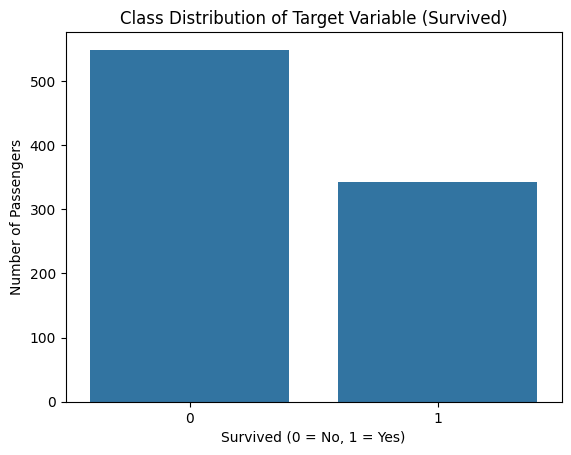

In [4]:
# Load the dataset (already loaded as 'df' if you've done this before)
# Count plot using seaborn
sns.countplot(x='Survived', data=data)
plt.title("Class Distribution of Target Variable (Survived)")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


# NearMiss(Version-1)

In [5]:
# Step 2: Separate features and target
X = data.drop('Survived', axis=1)
y = data['Survived']
nm1 = NearMiss(version=1)
X_res1, y_res1 = nm1.fit_resample(X, y)
sns.countplot(x=y_res1,data = data)
plt.title("After NearMiss Version 1 (Balanced Classes)")
plt.xlabel("Survived")
plt.ylabel("Number of Samples")
plt.show()


ValueError: Input X contains NaN.
NearMiss does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values